## Time series 
something different from cross-sections

series generated with AR(1), AR coefficient $ \rho $

In [1]:
# _tsa_00.py
# time series stuff, basic 
# 그리기
# 시계열, 추세, 계절성 조정, 이동평균, 이런 것들. 
# 자기공분산, 자기상관, 단위근 
# ARIMA 중 AR(p)
# 기타... 단순한 내용만 간략하게. 


import os
import numpy as np                          # numpy 라이브러리 전체. 
import pandas as pd                         # pandas 라이브러리 전체, 시계열(기본) 여기 있네. 
import matplotlib.pyplot as plt
from scipy import stats, optimize, linalg   # scipy 라이브러리 하부 모듈.
from statsmodels.tsa import stattools       # time series analysis 
from statsmodels.tsa.arima.model import ARIMA # 이거 가능하다 이거지. 이거 대문자네. 꼭. 
from statsmodels.tsa.ar_model import AutoReg


$ y\sim $ AR(1) 
\begin{align}
 y_ t & = \alpha y_{t-1} + e_t \\
 e_t & \sim iidN(0, \sigma^2 ) 
\end{align}

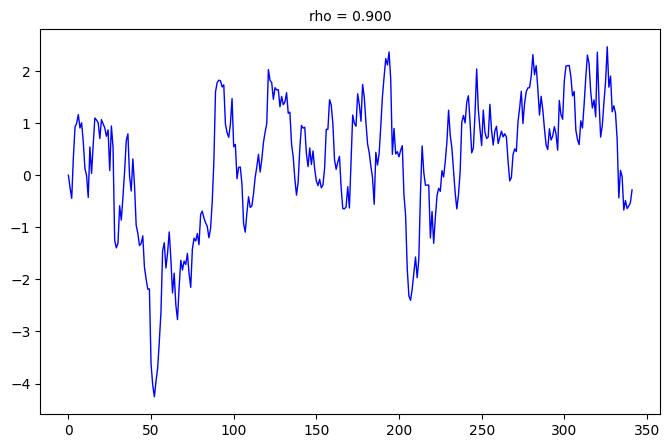

In [26]:

# 연습 데이터 생생 
n_obs = 342
rho = 0.9
seed = 135678942
np.random.seed(seed)

eps = np.random.normal( scale=np.sqrt(1-rho**2), size = n_obs )

y = np.zeros(n_obs)
x = np.zeros(n_obs)

for t in range(1, n_obs): 
    x[t] = t
    y[t] = rho*y[t-1] + eps[t]

plt.figure(figsize=(8, 5))
plt.plot(x, y, color='blue', linewidth=1)
plt.title(f"rho = {rho:.3f}", fontsize=10)

rhatmat = np.corrcoef(y[:-1], y[1:])   # :-1 ==> 마지막 제외, 1: 첫 제외
    #print(rhatmat)
    #np.corrcoef(y[:-k], y[k:])   # 마지막 k, 첫 k 제외. 


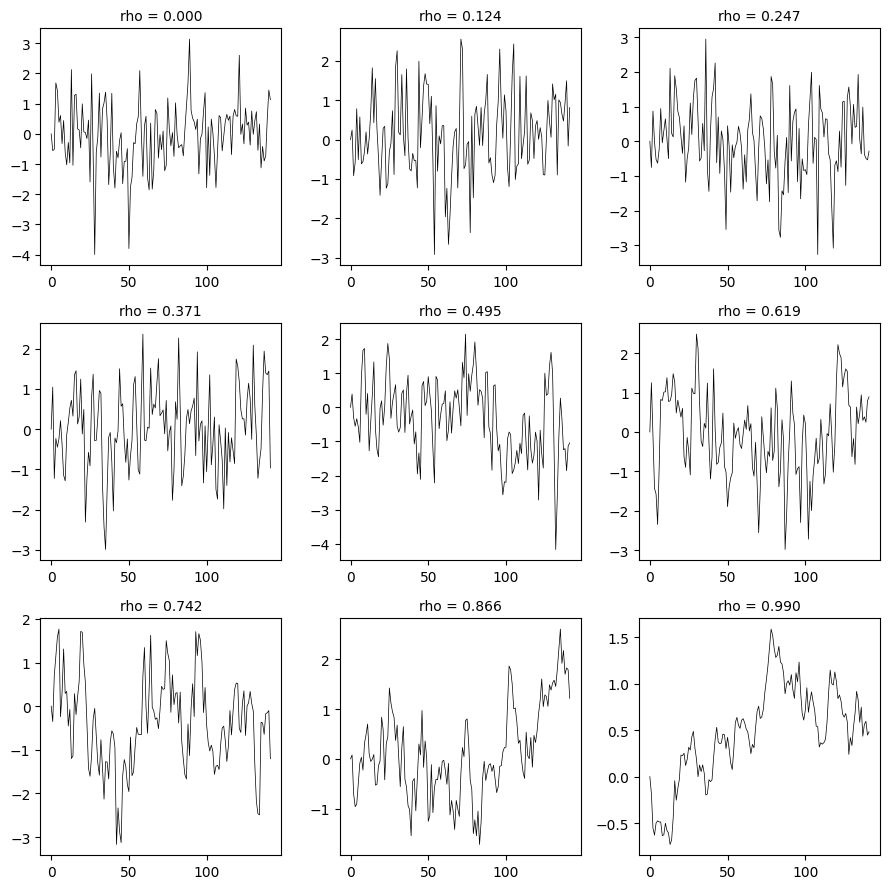

In [35]:
# 연습 데이터 생생, 위 셀 반복. 
# time series with rho = 0,..., 0.9

seed = 135678942
np.random.seed(seed)
n_obs = 142
n_rows = 3
n_cols = 3

n_figs = n_rows * n_cols 

rhos = np.linspace(0.0, 0.99, n_figs)  # a, b, 간격을 정확하게 c개로 구분한 값, 끝점 포함. 
# range()  # 끝점 포함하지 않음
# np.arange() # 끝점 불포함. 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(9, 9))
for ax, rho in zip( axes.flat, rhos )  :

    e_iid = np.random.normal( scale=np.sqrt(1-rho**2), size = n_obs )

    y = np.zeros(n_obs)
    x = np.zeros(n_obs)

    # index t
    for t in range(1, n_obs): 
        x[t] = t
        y[t] = rho*y[t-1] + e_iid[t]

    ax.plot(x, y, color='black', lw=0.51 )
#         ax.scatter(
#             x, y, 
#             s=25, 
#             marker='o',
#             facecolor='none',
#             edgecolor='black',
#             linewidths=1.5
#             #color='black', 요건 점으로 할 때.
#             #alpha=0.7
#             )
    ax.set_title(f"rho = {rho:.3f}", fontsize=10)
#         ax.set_xlim(-3.5, 3.5)
#         ax.set_ylim(-3.5, 3.5)
#         ax.set_aspect('equal')
#         ax.set_xticks([])
#    ax.set_yticks([])
plt.tight_layout()
plt.show()

